# Table Access Protocol (TAP) table joins
Ref: [TAP](https://dp1.lsst.io/tutorials/notebook/102/notebook-102-3.html)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from lsst.rsp import get_tap_service
from lsst.utils.plotting import (get_multiband_plot_colors,
                                 get_multiband_plot_symbols)

service = get_tap_service("tap")
assert service is not None

filters = pd.DataFrame.from_dict(get_multiband_plot_colors(), orient='index', columns=['color'])
dum = pd.DataFrame.from_dict(get_multiband_plot_symbols(), orient='index', columns=['symbol'])
filters = pd.merge(filters, dum, left_index=True, right_index=True)
del dum
filters

,color,symbol
u,#61A2B3,o
g,#31DE1F,^
r,#B52626,v
i,#1600EA,s
z,#BA52FF,*
y,#370201,p


In [2]:
queries = pd.DataFrame(columns=['select', 'from', 'join', 'on', 'where', 'order by'])
queries.loc['fsodo'] = ["visit, band, psfFlux",
                        "dp1.ForcedSourceOnDiaObject", "", "",
                        "diaObjectId = 614435753623027782", ""]
queries.loc['vis']  = ["visit, expMidptMJD", 
                       "dp1.Visit", "", "", "", ""]
queries.loc['join'] = ["fsodo.band, fsodo.psfFlux, vis.expMidptMJD", 
                       "dp1.ForcedSourceOnDiaObject as fsodo", 
                       "dp1.Visit as vis",
                       "vis.visit = fsodo.visit",
                        "fsodo.diaObjectId = 614435753623027782", ""]
cols = queries.columns
queries

,select,from,join,on,where,order by
fsodo,"visit, band, psfFlux",dp1.ForcedSourceOnDiaObject,,,diaObjectId = 614435753623027782,
vis,"visit, expMidptMJD",dp1.Visit,,,,
join,"fsodo.band, fsodo.psfFlux, vis.expMidptMJD",dp1.ForcedSourceOnDiaObject as fsodo,dp1.Visit as vis,vis.visit = fsodo.visit,fsodo.diaObjectId = 614435753623027782,


In [3]:
def grabout():
    for idx, dat in queries.iterrows():
        query = ''
        for col in cols:
            if dat[col] != '':
                query += f' {col.upper()} {dat[col]}'
        print(idx); print(query)
        if 'schema' not in dat['from']:
            job = service.submit_job(query)
            job.run()
            job.wait(phases=['COMPLETED', 'ERROR'])
            if job.phase == 'ERROR':
                job.raise_if_error()
            elif job.phase == 'COMPLETED':
                out = job.fetch_result().to_table()
        else:
            out = service.search(query).to_table()
        queries.loc[idx, 'out'] = out
        print(type(out), len(out))
#       display(out)
        print()
grabout()

fsodo
 SELECT visit, band, psfFlux FROM dp1.ForcedSourceOnDiaObject WHERE diaObjectId = 614435753623027782
<class 'astropy.table.table.Table'> 225

vis
 SELECT visit, expMidptMJD FROM dp1.Visit
<class 'astropy.table.table.Table'> 1786

join
 SELECT fsodo.band, fsodo.psfFlux, vis.expMidptMJD FROM dp1.ForcedSourceOnDiaObject as fsodo JOIN dp1.Visit as vis ON vis.visit = fsodo.visit WHERE fsodo.diaObjectId = 614435753623027782
<class 'astropy.table.table.Table'> 225



In [4]:
queries.loc['join', 'out']

band,psfFlux,expMidptMJD
,nJy,d
str1,float32,float64
u,49686.3,60647.30382497108
g,105209.0,60647.29871251729
g,104597.0,60647.299215243096
r,109597.0,60647.311318726905
u,49499.6,60647.30449173614
u,46731.6,60647.30509196191
g,94665.3,60646.320948107634
r,115779.0,60634.335898911944


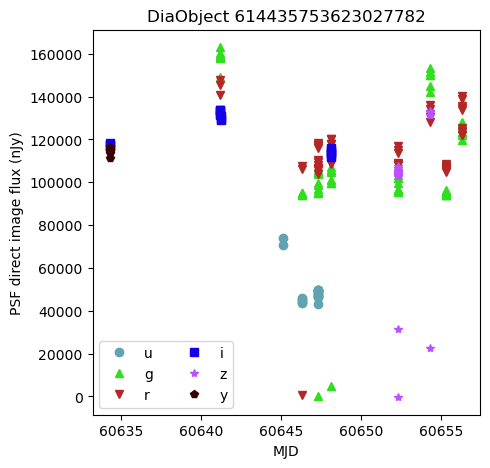

In [5]:
fig = plt.figure(figsize=(5, 5))
for band in filters.index:
    idx = np.where(queries.loc['join', 'out']['band'] == band)[0]
    dat = queries.loc['join', 'out'][idx]
    plt.plot(dat['expMidptMJD'],  dat['psfFlux'], filters.loc[band, 'symbol'],
             color=filters.loc[band, 'color'], label=band)
plt.xlabel('MJD')
plt.ylabel('PSF direct image flux (nJy)')
plt.legend(ncols=2)
plt.title('DiaObject 614435753623027782')
plt.show()